In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [4]:
BASE_DIR = '/mnt/c/Users/ASUS/Documents/Projects Data/Brain_Tumor_Dataset'
# print(os.listdir(BASE_DIR))

train_dir = os.path.join(BASE_DIR, 'Training')
validation_dir = os.path.join(BASE_DIR, 'Testing')


# print(os.listdir(validation_dir))

glioma_train_dir = os.path.join(train_dir, 'glioma')
meningioma_train_dir = os.path.join(train_dir, 'meningioma')
notumor_train_dir = os.path.join(train_dir, 'notumor')
pituitary_train_dir = os.path.join(train_dir, 'pituitary')

glioma_validation_dir = os.path.join(validation_dir, 'glioma')
meningioma_validation_dir = os.path.join(validation_dir, 'meningioma')
notumor_validation_dir = os.path.join(validation_dir, 'notumor')
pituitary_validation_dir = os.path.join(validation_dir, 'pituitary')

In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size =(150, 150),
    batch_size = 10,
    label_mode = 'categorical',
    color_mode = 'grayscale'
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size = (150, 150),
    batch_size = 10,
    label_mode = 'categorical',
    color_mode = 'grayscale'
)

Found 5712 files belonging to 4 classes.


I0000 00:00:1744647081.748994    3695 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 1311 files belonging to 4 classes.


In [6]:
train_dataset_final = train_dataset.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
validation_dataset_final = validation_dataset.cache().prefetch(tf.data.AUTOTUNE)

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(150, 150, 1)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')

])
model.compile(
    optimizer='Adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [8]:
history = model.fit(train_dataset_final, epochs=10, validation_data = validation_dataset_final, verbose=2)

Epoch 1/10


I0000 00:00:1744647152.519211    3800 service.cc:148] XLA service 0x7fbb2c00ab90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744647152.520467    3800 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-04-14 19:12:32.565488: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744647152.712839    3800 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1744647155.242478    3800 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


572/572 - 15s - 26ms/step - accuracy: 0.6730 - loss: 0.7935 - val_accuracy: 0.7879 - val_loss: 0.5381
Epoch 2/10
572/572 - 5s - 9ms/step - accuracy: 0.8577 - loss: 0.4057 - val_accuracy: 0.8444 - val_loss: 0.4225
Epoch 3/10
572/572 - 5s - 9ms/step - accuracy: 0.9086 - loss: 0.2567 - val_accuracy: 0.8719 - val_loss: 0.3124
Epoch 4/10
572/572 - 5s - 9ms/step - accuracy: 0.9368 - loss: 0.1774 - val_accuracy: 0.9336 - val_loss: 0.1931
Epoch 5/10
572/572 - 5s - 9ms/step - accuracy: 0.9492 - loss: 0.1510 - val_accuracy: 0.9161 - val_loss: 0.2084
Epoch 6/10
572/572 - 5s - 9ms/step - accuracy: 0.9646 - loss: 0.1139 - val_accuracy: 0.9436 - val_loss: 0.1797
Epoch 7/10
572/572 - 5s - 9ms/step - accuracy: 0.9711 - loss: 0.0819 - val_accuracy: 0.9390 - val_loss: 0.1684
Epoch 8/10
572/572 - 5s - 9ms/step - accuracy: 0.9776 - loss: 0.0740 - val_accuracy: 0.9558 - val_loss: 0.1491
Epoch 9/10
572/572 - 5s - 9ms/step - accuracy: 0.9820 - loss: 0.0549 - val_accuracy: 0.9489 - val_loss: 0.2109
Epoch 10/1

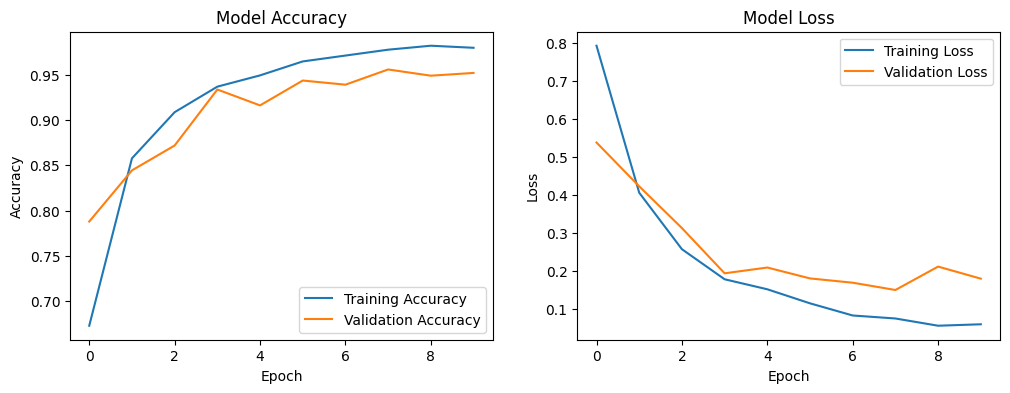

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.legend()
################################
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.legend()

plt.show()

In [12]:
# Alternatively save as TensorFlow SavedModel
model.save('brain_tumor_classifier')

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=brain_tumor_classifier.

In [13]:
# Fix the ValueError by using correct saving methods

# Option 1: Save in modern Keras format (.keras)
model.save('brain_tumor_classifier.keras')  # Recommended format

# Option 2: Export as SavedModel format (for TF Serving/Lite)
model.export('brain_tumor_classifier')  # Creates directory with assets/variables


INFO:tensorflow:Assets written to: brain_tumor_classifier/assets


INFO:tensorflow:Assets written to: brain_tumor_classifier/assets


Saved artifact at 'brain_tumor_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140446250328592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250330512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250330128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250330896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250330704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250331280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250330320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250332240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250332624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140446250333584: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [14]:
# Save in Keras format (single file)
model.save('brain_tumor_classifier.keras')  

# Verify file creation
import os
print(f".keras exists: {os.path.exists('brain_tumor_classifier.keras')}")


.keras exists: True
